In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("data/online_retail_II.csv")

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1067371
Number of columns: 8


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [6]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 34335


In [8]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [9]:
cancelled_invoices = df['Invoice'].astype(str).str.startswith('C')

print("Cancelled transactions:", cancelled_invoices.sum())

Cancelled transactions: 19494


In [10]:
print("Negative quantities:", (df['Quantity'] < 0).sum())

Negative quantities: 22950


In [11]:
print("Non-positive prices:", (df['Price'] <= 0).sum())

Non-positive prices: 6207


In [12]:
 # Create a copy of the original dataset
df_clean = df.copy()

# Remove rows with missing Customer ID
df_clean = df_clean.dropna(subset=['Customer ID'])

# Remove duplicate transactions
df_clean = df_clean.drop_duplicates()

# Remove cancelled invoices
df_clean = df_clean[
    ~df_clean['Invoice'].astype(str).str.startswith('C')
]

# Keep only positive quantities
df_clean = df_clean[df_clean['Quantity'] > 0]

# Keep only positive prices
df_clean = df_clean[df_clean['Price'] > 0]

# Convert InvoiceDate to datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))

Original rows: 1067371
Cleaned rows: 779425


In [13]:
df_clean.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [14]:
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


In [15]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  str           
 1   StockCode    779425 non-null  str           
 2   Description  779425 non-null  str           
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[us]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  float64       
 7   Country      779425 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 53.5 MB


In [16]:
print("Negative quantities:", (df_clean['Quantity'] < 0).sum())
print("Non-positive prices:", (df_clean['Price'] <= 0).sum())
print("Cancelled invoices:", df_clean['Invoice'].astype(str).str.startswith('C').sum())

Negative quantities: 0
Non-positive prices: 0
Cancelled invoices: 0


In [17]:
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['Price']

In [18]:
df_clean[['Quantity', 'Price', 'TotalAmount']].head()

,Quantity,Price,TotalAmount
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [19]:
df_clean[['Quantity', 'Price', 'TotalAmount']].describe()

,Quantity,Price,TotalAmount
count,779425.000000,779425.000000,779425.000000
mean,13.489370,3.218488,22.291823
std,145.855814,29.676140,227.427075
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.480000
75%,12.000000,3.750000,19.800000
max,80995.000000,10953.500000,168469.600000


In [20]:
print("Total Revenue:", df_clean['TotalAmount'].sum())
print("Average Transaction Value:", df_clean['TotalAmount'].mean())

Total Revenue: 17374804.268
Average Transaction Value: 22.291823161946304


In [22]:
print("First transaction:", df_clean['InvoiceDate'].min())
print("Last transaction:", df_clean['InvoiceDate'].max())

First transaction: 2009-12-01 07:45:00
Last transaction: 2011-12-09 12:50:00


In [23]:
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Reference date:", reference_date)

Reference date: 2011-12-10 12:50:00


In [24]:
rfm = df_clean.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalAmount': 'sum'
}).reset_index()

rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']

In [28]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [26]:
print("Number of customers:", rfm['Customer ID'].nunique())
print("RFM records:", len(rfm))

Number of customers: 5878
RFM records: 5878


In [27]:
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,342.280000
50%,96.000000,3.000000,867.740000
75%,380.000000,7.000000,2248.305000
max,739.000000,398.000000,580987.040000


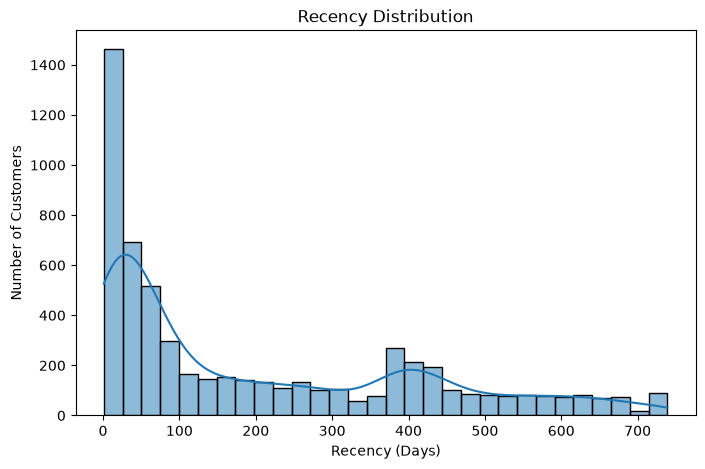

In [29]:
plt.figure(figsize=(8, 5))

sns.histplot(rfm['Recency'], bins=30, kde=True)

plt.title('Recency Distribution')
plt.xlabel('Recency (Days)')
plt.ylabel('Number of Customers')
plt.show()

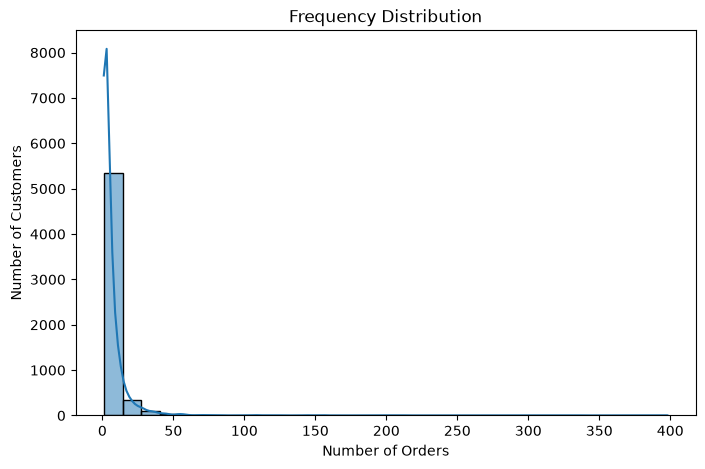

In [30]:
plt.figure(figsize=(8, 5))

sns.histplot(rfm['Frequency'], bins=30, kde=True)

plt.title('Frequency Distribution')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.show()

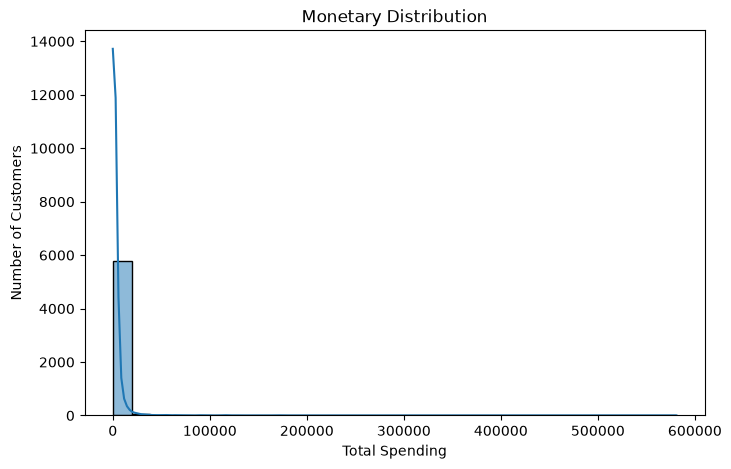

In [31]:
plt.figure(figsize=(8, 5))

sns.histplot(rfm['Monetary'], bins=30, kde=True)

plt.title('Monetary Distribution')
plt.xlabel('Total Spending')
plt.ylabel('Number of Customers')
plt.show()

In [32]:
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].copy()
rfm_log = np.log1p(rfm_log)

rfm_log.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,4.454132,1.549588,6.816979
std,1.559404,0.809447,1.385486
min,0.693147,0.693147,1.373716
25%,3.295837,0.693147,5.838546
50%,4.574711,1.386294,6.767044
75%,5.942799,2.079442,7.718377
max,6.606650,5.988961,13.272485


In [33]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

print("Scaled RFM shape:", rfm_scaled.shape)

Scaled RFM shape: (5878, 3)


In [34]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

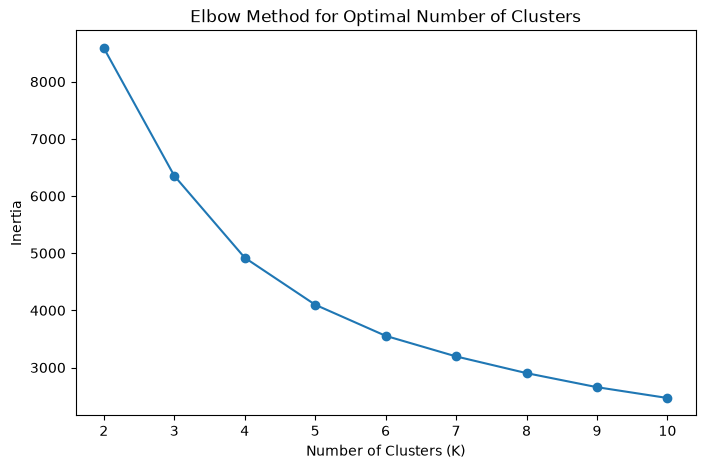

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker='o')

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(2, 11))
plt.show()

In [36]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [37]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,12,77556.46,2
1,12347.0,2,8,4921.53,2
2,12348.0,75,5,2019.40,3
3,12349.0,19,4,4428.69,1
4,12350.0,310,1,334.40,0


In [38]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

print(cluster_counts)

Cluster
0    1973
1    1250
2    1196
3    1459
Name: count, dtype: int64


In [39]:
print("Total customers:", cluster_counts.sum())

Total customers: 5878


In [40]:
cluster_profile = rfm.groupby('Cluster')[[
    'Recency',
    'Frequency',
    'Monetary'
]].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,394.95,1.38,317.08
1,28.30,3.05,857.49
2,27.71,19.28,10731.16
3,230.07,5.06,1948.50


In [41]:
cluster_profile['Customer Count'] = rfm.groupby('Cluster').size()

cluster_profile

,Recency,Frequency,Monetary,Customer Count
Cluster,,,,
0,394.95,1.38,317.08,1973
1,28.30,3.05,857.49,1250
2,27.71,19.28,10731.16,1196
3,230.07,5.06,1948.50,1459


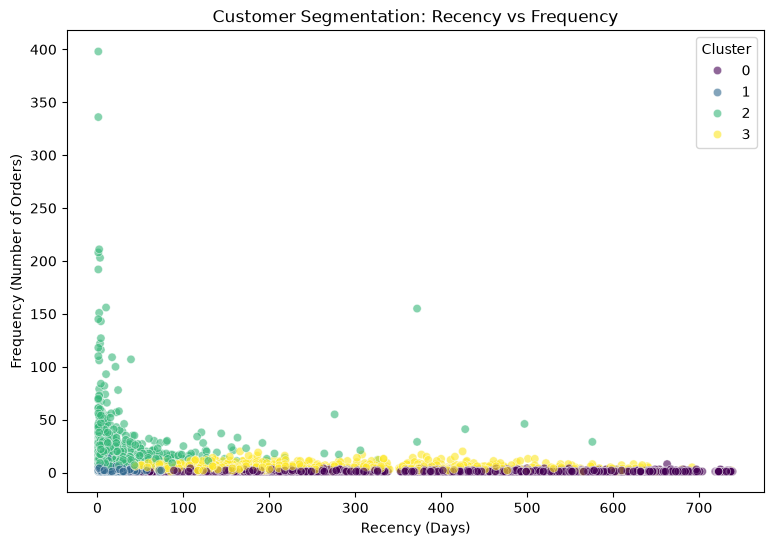

In [42]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Cluster',
    palette='viridis',
    alpha=0.6
)

plt.title('Customer Segmentation: Recency vs Frequency')
plt.xlabel('Recency (Days)')
plt.ylabel('Frequency (Number of Orders)')
plt.legend(title='Cluster')
plt.show()

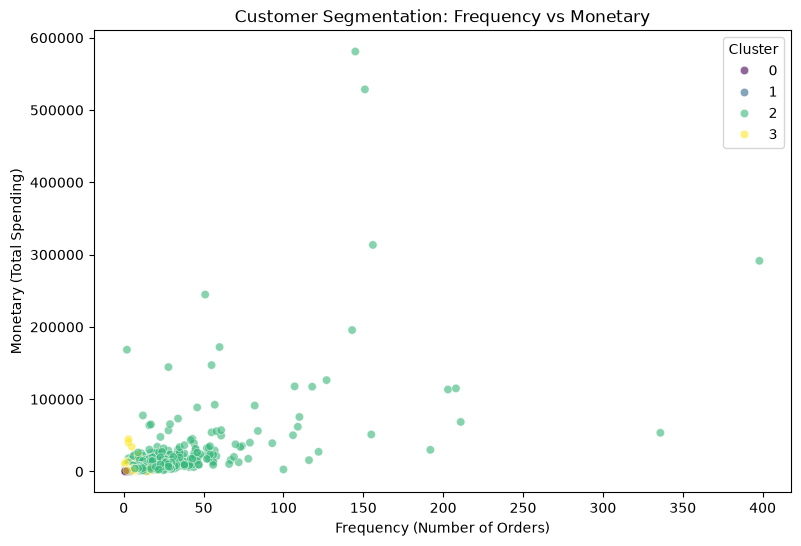

In [43]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    alpha=0.6
)

plt.title('Customer Segmentation: Frequency vs Monetary')
plt.xlabel('Frequency (Number of Orders)')
plt.ylabel('Monetary (Total Spending)')
plt.legend(title='Cluster')
plt.show()

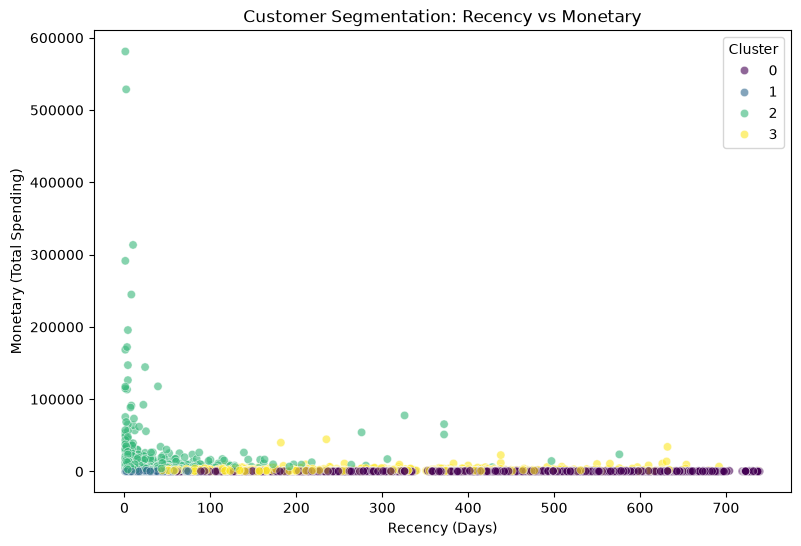

In [44]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    alpha=0.6
)

plt.title('Customer Segmentation: Recency vs Monetary')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary (Total Spending)')
plt.legend(title='Cluster')
plt.show()

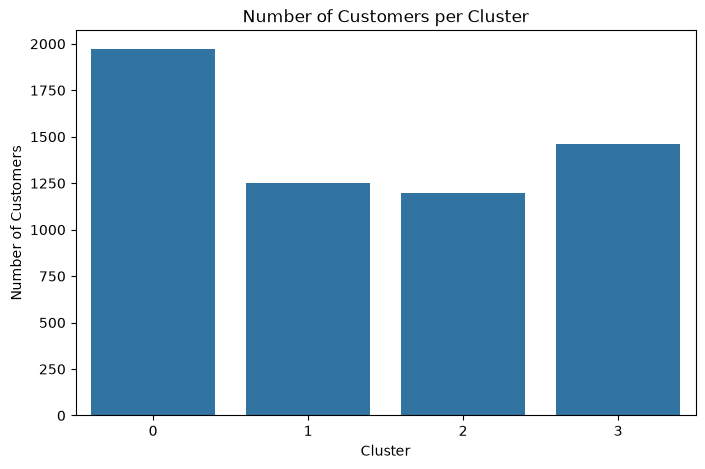

In [45]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

plt.show()

In [46]:
segment_names = {
    0: 'Lost / Low-Value Customers',
    1: 'Recent Customers',
    2: 'Champions',
    3: 'At-Risk Customers'
}

rfm['Segment'] = rfm['Cluster'].map(segment_names)

In [47]:
rfm[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']].head(10)

,Customer ID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,12,77556.46,2,Champions
1,12347.0,2,8,4921.53,2,Champions
2,12348.0,75,5,2019.40,3,At-Risk Customers
3,12349.0,19,4,4428.69,1,Recent Customers
4,12350.0,310,1,334.40,0,Lost / Low-Value Customers
5,12351.0,375,1,300.93,0,Lost / Low-Value Customers
6,12352.0,36,10,2849.84,2,Champions
7,12353.0,204,2,406.76,0,Lost / Low-Value Customers
8,12354.0,232,1,1079.40,0,Lost / Low-Value Customers
9,12355.0,214,2,947.61,3,At-Risk Customers


In [48]:
segment_profile = rfm.groupby('Segment').agg(
    Customer_Count=('Customer ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(2)

segment_profile

,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
At-Risk Customers,1459,230.07,5.06,1948.50
Champions,1196,27.71,19.28,10731.16
Lost / Low-Value Customers,1973,394.95,1.38,317.08
Recent Customers,1250,28.30,3.05,857.49


In [49]:
segment_profile['Customer_Percentage'] = (
    segment_profile['Customer_Count'] / len(rfm) * 100
).round(2)

segment_profile

,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Percentage
Segment,,,,,
At-Risk Customers,1459,230.07,5.06,1948.50,24.82
Champions,1196,27.71,19.28,10731.16,20.35
Lost / Low-Value Customers,1973,394.95,1.38,317.08,33.57
Recent Customers,1250,28.30,3.05,857.49,21.27


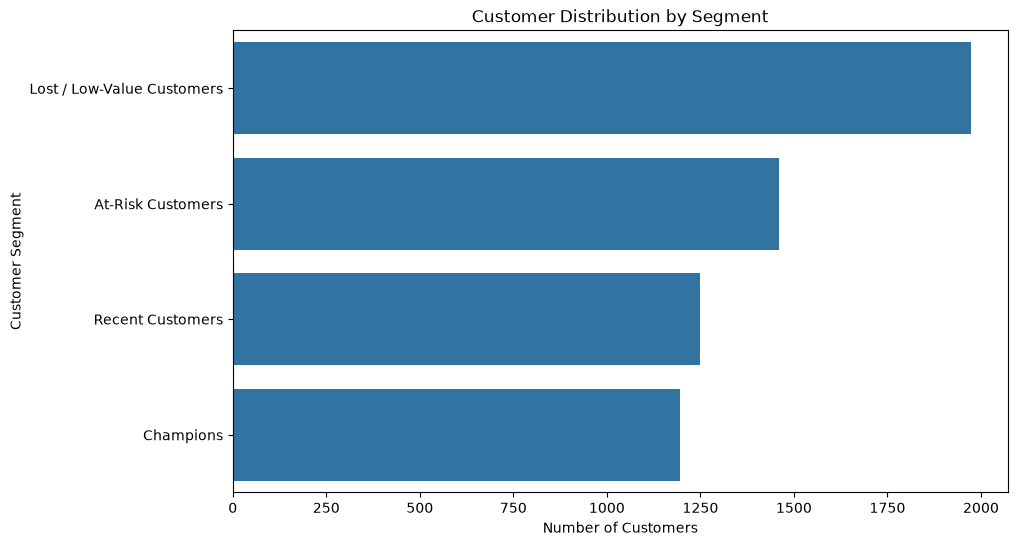

In [50]:
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_counts.values,
    y=segment_counts.index
)

plt.title('Customer Distribution by Segment')
plt.xlabel('Number of Customers')
plt.ylabel('Customer Segment')

plt.show()

In [51]:
marketing_strategy = pd.DataFrame({
    'Segment': [
        'Champions',
        'Recent Customers',
        'At-Risk Customers',
        'Lost / Low-Value Customers'
    ],
    'Strategy': [
        'VIP rewards, exclusive offers, early access and referral incentives',
        'Cross-selling, personalized recommendations and loyalty incentives',
        'Win-back campaigns, personalized discounts and reactivation offers',
        'Low-cost promotional campaigns and selective re-engagement'
    ]
})

marketing_strategy

,Segment,Strategy
0,Champions,"VIP rewards, exclusive offers, early access an..."
1,Recent Customers,"Cross-selling, personalized recommendations an..."
2,At-Risk Customers,"Win-back campaigns, personalized discounts and..."
3,Lost / Low-Value Customers,Low-cost promotional campaigns and selective r...


In [52]:
print("Total customers:", len(rfm))
print("Missing values:")
print(rfm[['Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']].isnull().sum())

Total customers: 5878
Missing values:
Recency      0
Frequency    0
Monetary     0
Cluster      0
Segment      0
dtype: int64


In [53]:
print(rfm['Cluster'].value_counts().sort_index())

Cluster
0    1973
1    1250
2    1196
3    1459
Name: count, dtype: int64


In [54]:
segment_summary = rfm.groupby('Segment').agg(
    Customers=('Customer ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(2)

segment_summary['Percentage'] = (
    segment_summary['Customers'] / len(rfm) * 100
).round(2)

segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Percentage
Segment,,,,,
At-Risk Customers,1459,230.07,5.06,1948.50,24.82
Champions,1196,27.71,19.28,10731.16,20.35
Lost / Low-Value Customers,1973,394.95,1.38,317.08,33.57
Recent Customers,1250,28.30,3.05,857.49,21.27


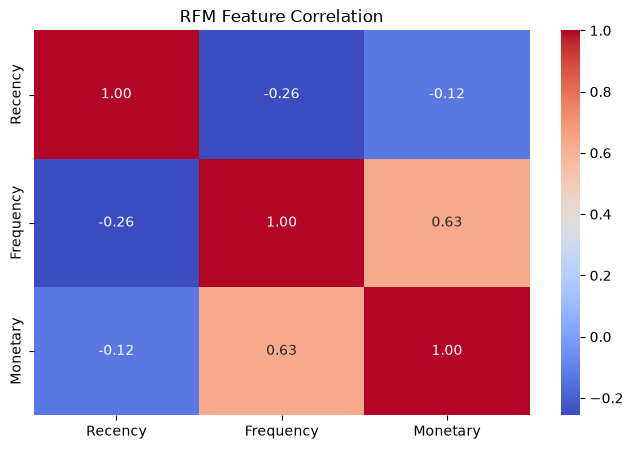

In [55]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    rfm[['Recency', 'Frequency', 'Monetary']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('RFM Feature Correlation')
plt.show()

In [56]:
rfm.to_csv(
    'data/customer_rfm_segments.csv',
    index=False
)